# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

**First, use the following code snippet to set a plot style close to those used in financial markets.**

---

In [2]:
# GIVEN
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

In [3]:
# part 1, task 1 & 2, GIVEN

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# 1. Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Use a User-Agent header
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers)
    # Use pandas to read the HTML content from the response text
    table = pd.read_html(response.text)
    sp500_df = table[0]
    tickers = sp500_df['Symbol'].tolist()
    print(f"Successfully retrieved {len(tickers)} tickers.")
except Exception as e:
    print(f"Error fetching tickers: {e}")
    # Fallback: A tiny subset in case Wikipedia is completely unreachable
    tickers = tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMD', 'GOOG', 'META', # Big Tech
    'JPM', 'BAC', 'GS', 'MS', 'WFC', # Banks
    'XOM', 'CVX', 'COP', 'SLB', # Energy
    'JNJ', 'PFE', 'MRK', 'LLY', # Pharma
    'KO', 'PEP', 'PG', 'WMT', 'COST', # Consumer Staples
    'BA', 'CAT', 'LMT', # Industrial
    'NEE', 'DUK' # Utilities
]

# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace('.', '-') for t in tickers]

# 2. Download 5 Years of Historical Data
# We focus only on 'Adj Close' to account for dividends and splits.
print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)


# Downloading the full universe
raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1d')['Close']
raw_data.index = raw_data.index.date
print("Done!")


Fetching S&P 500 ticker list...


/tmp/ipykernel_28646/1086746856.py:22: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


Successfully retrieved 503 tickers.


[*********************100%***********************]  503 of 503 completed


Done!


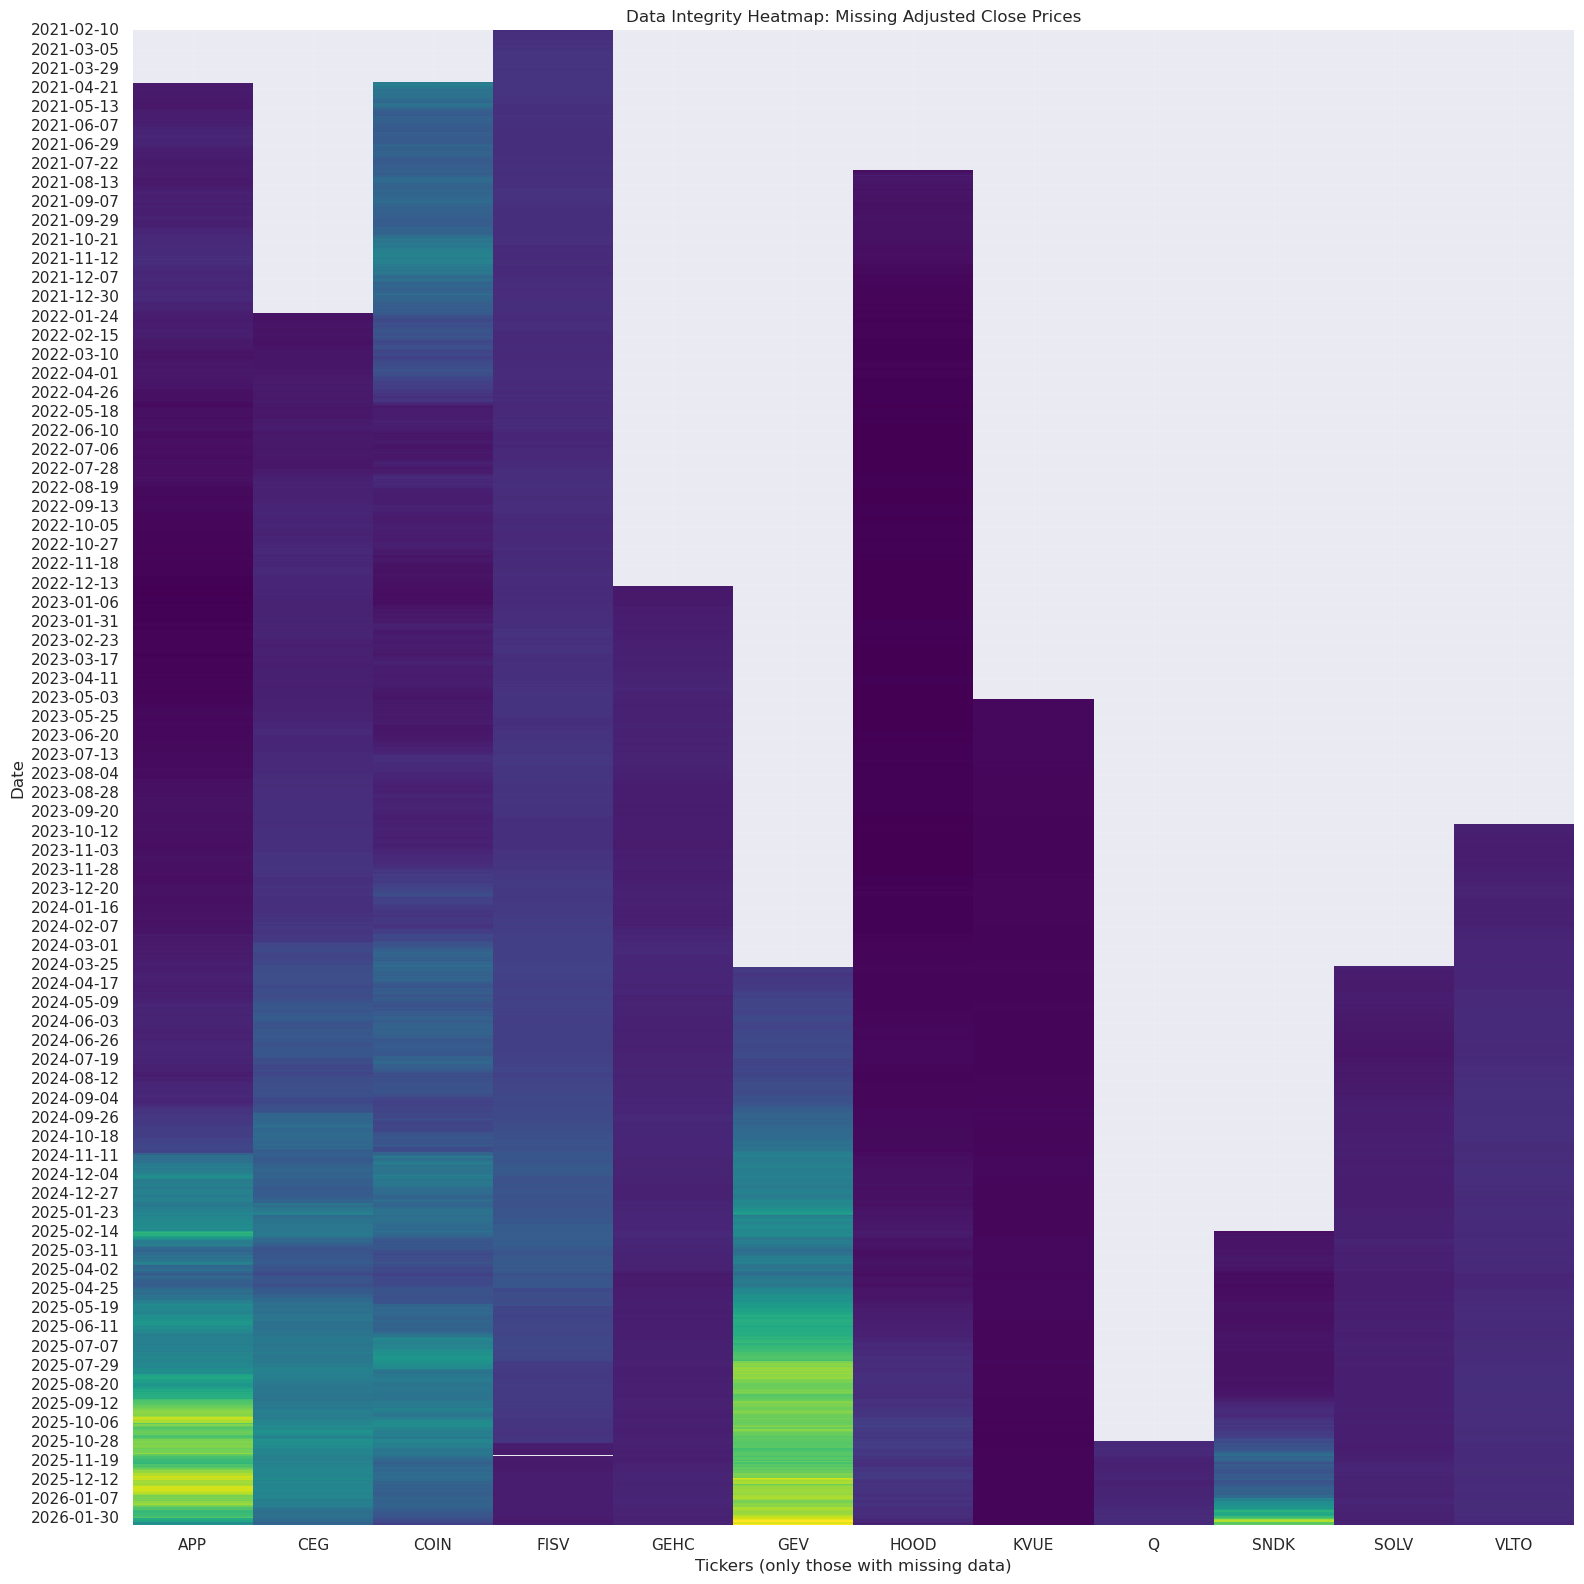

In [4]:
# part 1, task 3

data_missing = raw_data.isna().any()
only_have_data_missing = raw_data.loc[:, data_missing]

plt.figure(figsize=(16,16))
sns.heatmap(
    only_have_data_missing,
    cmap="viridis",
    cbar = False,
)

plt.title("Data Integrity Heatmap: Missing Adjusted Close Prices")
plt.xlabel("Tickers (only those with missing data)")
plt.ylabel("Date")

plt.tight_layout()
plt.show()

## Part 2: Volatility & Risk

**The Objective:** 
In the world of quantitative trading, **Price is a liar.** A $10 move in a $100 stock is massive; a $10 move in a $3,000 stock is noise. To compare apples to apples, Quants transform prices into **Log Returns** or **Percentage Returns**. This process, known as making the data "stationary," allows us to apply statistical models.

In this section, you will stop looking at how much a stock is *worth* and start looking at how much it *moves*. We will explore "Volatility" (the heartbeat of the market) and visualize the distribution of returns to see if the market truly follows a "Normal Distribution" (spoiler: it usually doesn't).

### Your Tasks:
1.  **Calculate Daily Returns:** Convert your cleaned price dataframe into daily percentage changes. 
2.  **The Heartbeat (Volatility Map):** Calculate the rolling 30-day standard deviation (volatility) for the entire S&P 500. Create a visualization that compares the volatility of different **Sectors** (e.g., are Tech stocks objectively "shakier" than Consumer Staples?).
3.  **The Distribution of Fear:** Plot a Histogram of the daily returns for the S&P 500 index. Overlay a "Normal Distribution" curve over it (hint: use the mean and the standard deviation of the whole dataset). 
4.  **Interactive Deep Dive:** Use `Plotly` to create a professional-grade interactive Candlestick chart for a few high-profile stocks (e.g., NVDA, TSLA, or MSFT). Include a subplot for **Volume** to see if price moves are backed by "conviction."

### Critical Thinking Questions:
*   **The Fat Tail Problem:** When you look at the Histogram of returns, do the "tails" (the extreme ends) match the Normal Distribution curve? If the "tails" are thicker (Kurtosis), what does that imply about the frequency of market crashes versus what standard statistics predict?
*   **Volatility Clustering:** Look at a time-series plot of returns (pick a stock of your choice). Do you notice that "calm" periods are followed by calm, and "volatile" periods are followed by volatile ones? This is a famous phenomenon. How would a trader use this information?
*   **The Volume Signal:** In your candlestick chart, look for a day with a massive price move. Was the Volume higher than average that day? Why do Quants say "Volume precedes price"?

---

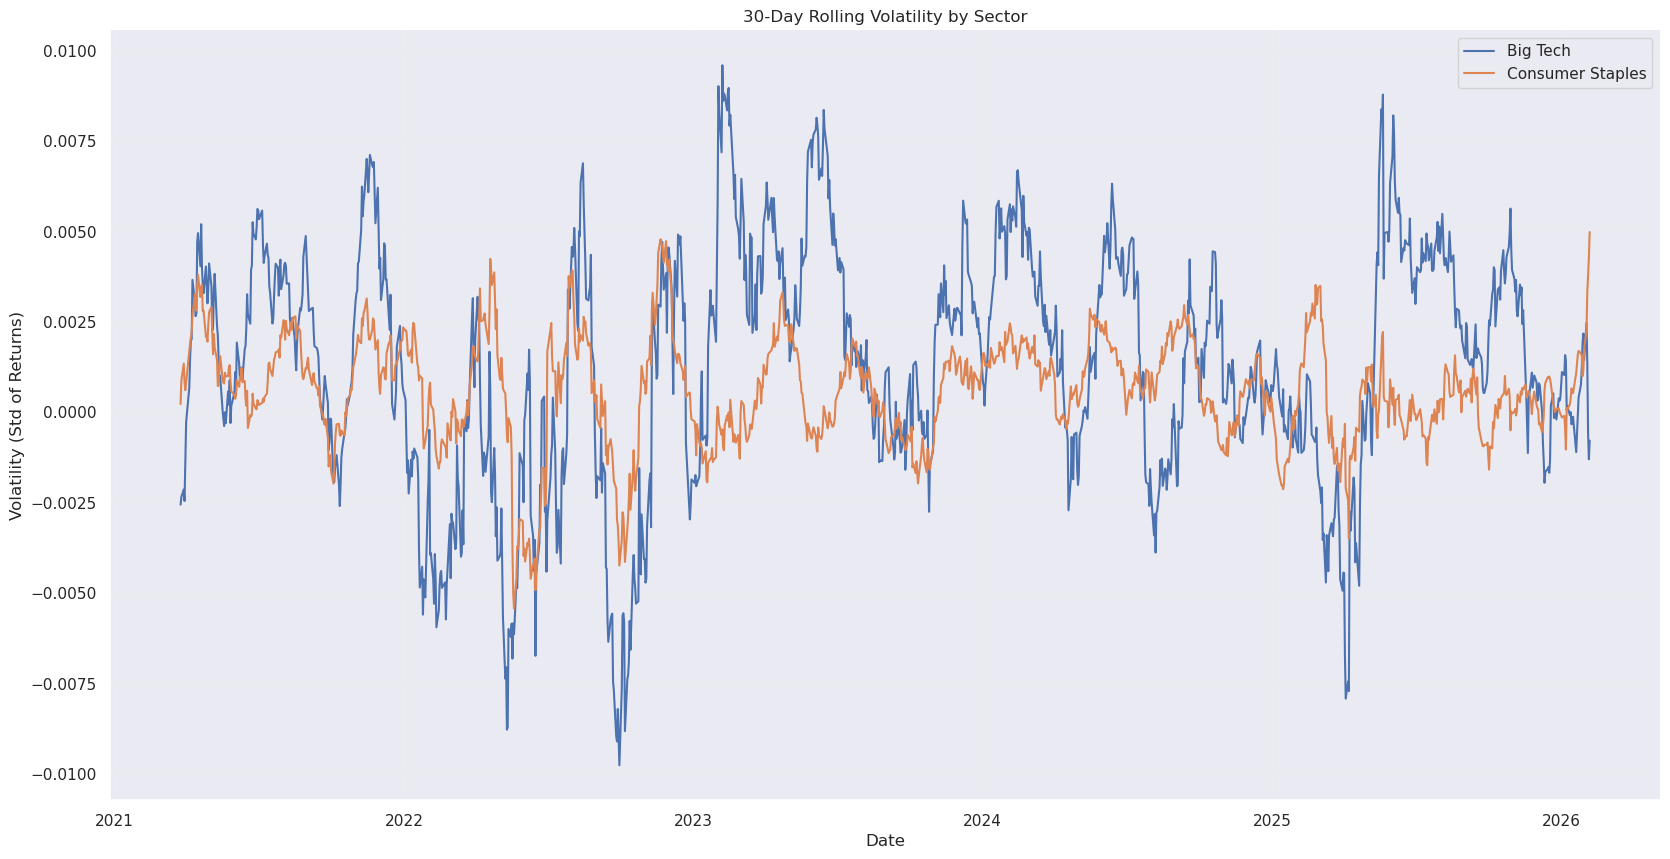

In [ ]:
# part 2, task 1 & 2

per_data = raw_data.pct_change(fill_method=None)
per_data = per_data.dropna(how="all")

per_data.describe(include='all')

big_tech = ['AAPL', 'MSFT', 'NVDA', 'AMD', 'GOOG', 'META']
banks = ['JPM', 'BAC', 'GS', 'MS', 'WFC']
energy = ['XOM', 'CVX', 'COP', 'SLB']
pharma = ['JNJ', 'PFE', 'MRK', 'LLY']
consumer_staples = ['KO', 'PEP', 'PG', 'WMT', 'COST']
industrial = ['BA', 'CAT', 'LMT']
utilities = ['NEE', 'DUK']

volatility = per_data.rolling(window=30).mean()
vol_of_sectors = {
    "Big Tech": volatility[big_tech].mean(axis=1),
    #"Banks": volatility[banks].mean(axis=1),
    #"Energy": volatility[energy].mean(axis=1),
    #"Pharma": volatility[pharma].mean(axis=1),
    "Consumer Staples": volatility[consumer_staples].mean(axis=1),
    #"Industrial": volatility[industrial].mean(axis=1),
    #"Utilities": volatility[utilities].mean(axis=1),
}

vol_sector_df = pd.DataFrame(vol_of_sectors)


plt.figure(figsize=(20, 10))
for sector in vol_sector_df.columns:
    plt.plot(vol_sector_df.index, vol_sector_df[sector], label=sector)

plt.title("30-Day Rolling Volatility by Sector")
plt.ylabel("Volatility (Std of Returns)")
plt.xlabel("Date")
plt.legend()
plt.show()

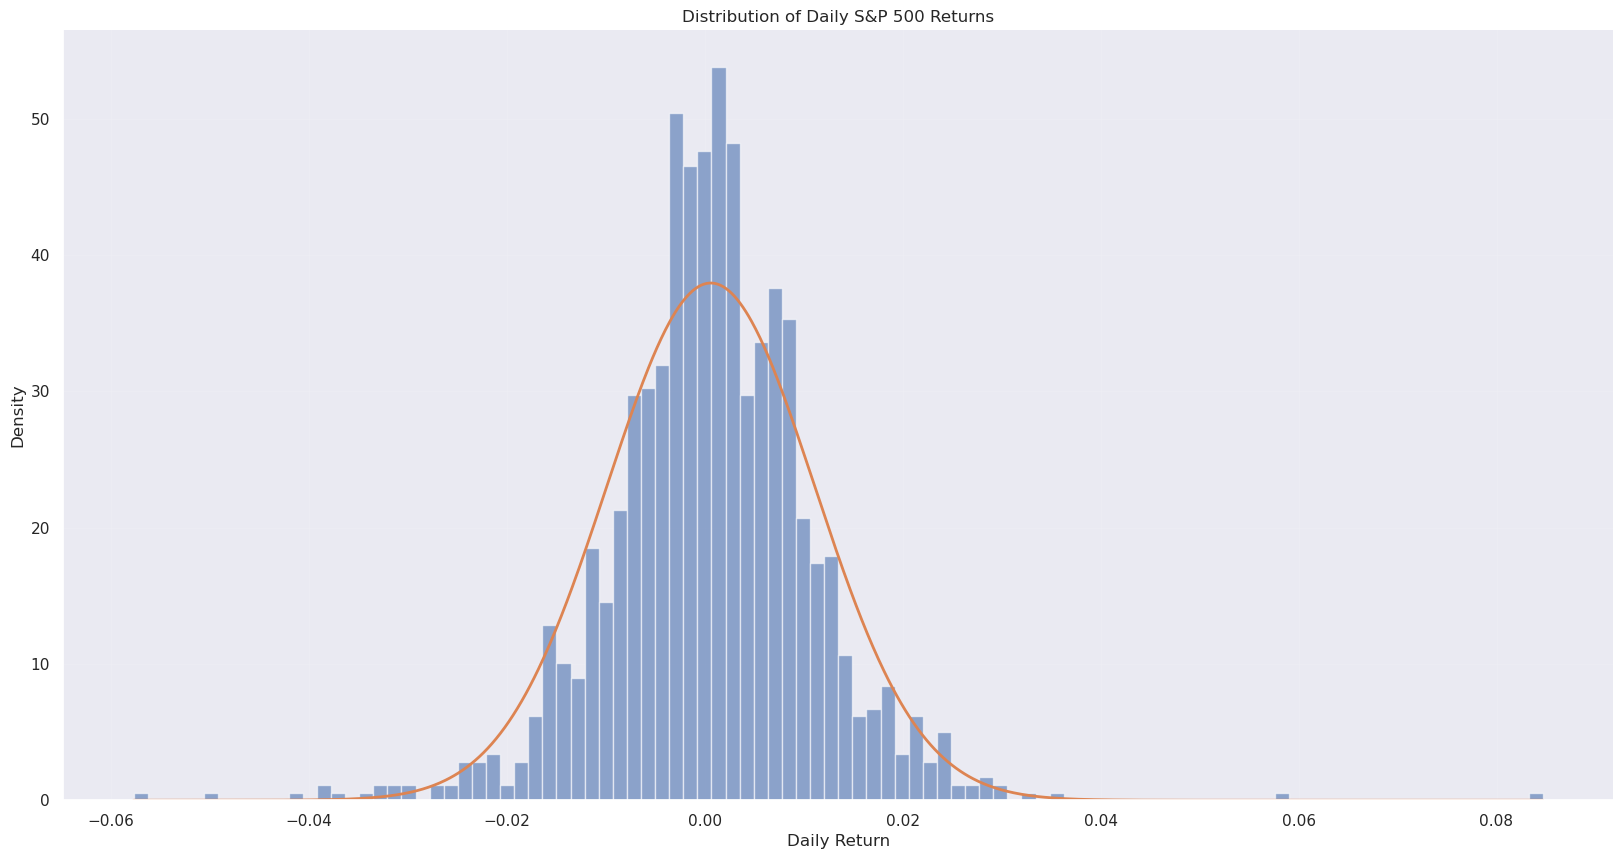

In [6]:
# part 2, task 3

import numpy as np
from scipy.stats import norm

sp500_data = per_data.mean(axis=1)

sp500_mean = sp500_data.mean()
sp500_std = sp500_data.std()

plt.figure(figsize=(20,10))

plt.hist(sp500_data, bins=100, density=True, alpha=0.6)

x = np.linspace(sp500_data.min(), sp500_data.max(), 1000)
plt.plot(x, norm.pdf(x, sp500_mean, sp500_std), linewidth=2)


plt.title("Distribution of Daily S&P 500 Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.show()

In [7]:
# part 2, task 4

hp_tickers = ["NVDA", "TSLA", "MSFT"]
hp_data = yf.download(tickers, period="1y", group_by="ticker")

[*********************100%***********************]  503 of 503 completed


In [8]:
# part 2, task 4

import plotly.graph_objects as go
from plotly.subplots import make_subplots

for hp in hp_tickers:
    df = hp_data[hp]
    
    x_min = "2025-11-01"
    x_max = "2026-02-1"
    x_range = [x_min, x_max]

    df_zoom = df.loc[x_min:x_max]
    y_min = df["Low"].min() + 90 # min() also counts very low outlier that are not shown, hence the '+ 80'.
    y_max = df["High"].max()
    padding = (y_max - y_min) * 0.1

    print(y_min)

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        row_heights=[1, 1]
    )

    # Candlestick
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df["Open"],
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        name="Price"
    ), row=1, col=1)

    # Volume
    fig.add_trace(go.Bar(
        x=df.index,
        y=df["Volume"],
        name="Volume"
    ), row=2, col=1)

    fig.update_layout(
        title=f"{hp} Candlestick Chart with Volume",
        xaxis_rangeslider_visible=False
    )

    fig.update_xaxes(range=x_range)
    fig.update_yaxes(range=[y_min - padding, y_max + padding], row=1, col=1)

    fig.show()


176.60427995314998


304.25


432.9514979578054


## Part 3: The Correlation Matrix & Hierarchical Maps

**The Objective:** 
In a crisis, diversification is often the only "free lunch" in finance. However, that lunch disappears if all your stocks move in lockstep. To a Quant, a 500x500 correlation matrix is a map of hidden dependencies. However, looking at a raw table of 250,000 correlation pairs is impossible for the human eye. 

In this section, you will use **Hierarchical Clustering** to reorganize the S&P 500. Instead of listing stocks alphabetically (A-Z), we will use an algorithm to group stocks that "behave" similarly. This will reveal the true "Tribes" of the market, which may or may not align with their official industry sectors.

### Your Tasks:
1.  **Compute the Correlation Matrix:** Calculate the Pearson correlation coefficient for the daily returns of all stocks in your cleaned dataset.
2.  **The Hierarchical Clustermap:** Create a massive, high-resolution `clustermap`. Use a diverging color palette (e.g., `coolwarm` or `RdBu`) centered at zero.
    *   *Pro Tip:* Use the `method='ward'` or `method='complete'` in your clustering to find distinct, compact groups.
3.  **Identify the "Anti-Correlators":** Find and visualize the relationship between two stocks with a correlation close to zero or negative. In a sea of positive correlation, these are the "diversifiers."

### Critical Thinking Questions:
*   **Data vs. Label:** Look at the clusters formed by the algorithm. Do they perfectly match the official GICS sectors (e.g., does every "Energy" stock sit in the same cluster)? If a specific Tech stock is clustering with "Utilities," what does that tell you about its risk profile?
*   **The "Sea of Red":** During periods of extreme market stress, correlations tend to "go to 1.0" (everything falls together). If you were to run this analysis using only data from the 2008 or 2020 crashes, how would the visual density of the clustermap change?
*   **Spurious Correlation:** If you find two stocks that are 90% correlated but are in completely different industries (e.g., a Gold miner and a Tech company), is that a "signal" you can trade, or just a statistical coincidence? How would you test the difference?

---

In [16]:
# part 3, task 1 & 2

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

sp500 = tables[0][["Symbol", "GICS Sector"]].copy()

sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)

ticker_to_sector = sp500.set_index("Symbol")["GICS Sector"].to_dict()

/tmp/ipykernel_28646/3694754395.py:9: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



/home/DroneBeta/.local/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/home/DroneBeta/.local/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



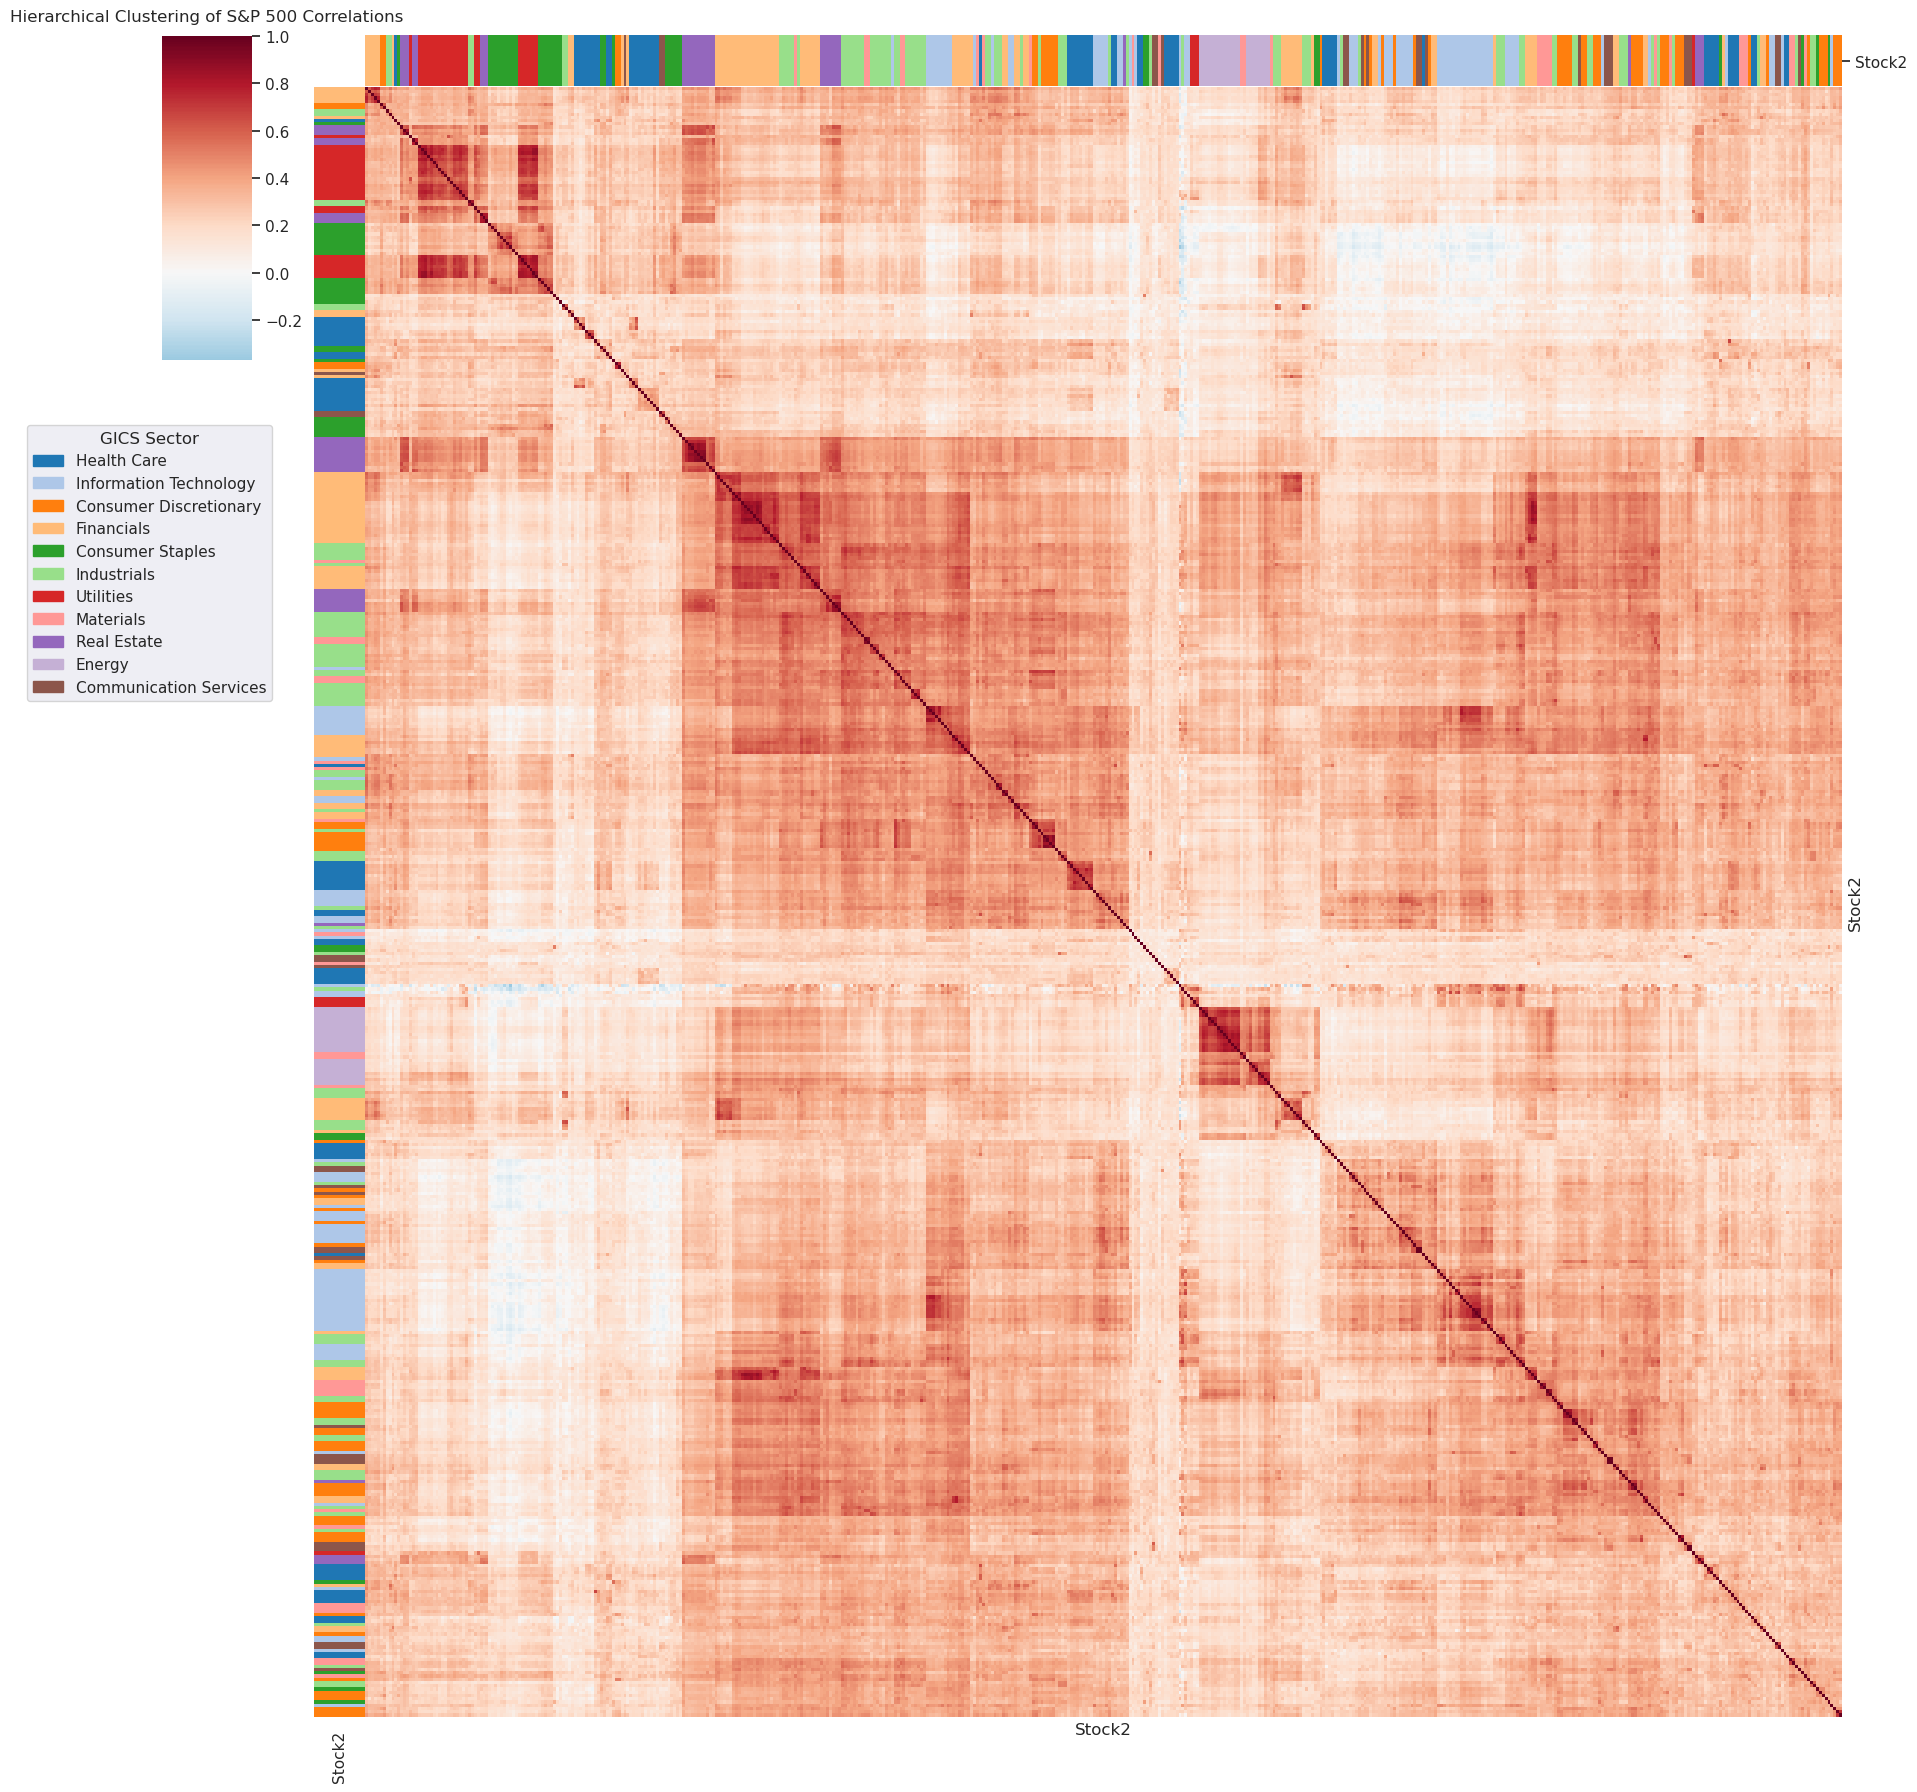

In [ ]:
# part 3, task 1 & 2

import matplotlib.patches as mpatches

tickers = per_data.columns

stock_sectors = pd.Series(tickers).map(ticker_to_sector)
stock_sectors.index = tickers

unique_sectors = stock_sectors.unique()
palette = sns.color_palette("tab20", len(unique_sectors))
sector_color_map = dict(zip(unique_sectors, palette))

row_colors = stock_sectors.map(sector_color_map)

corr_matrix = per_data.corr()
corr_matrix.describe()

g = sns.clustermap(
    corr_matrix,
    method="complete", # ward or complete
    cmap="RdBu_r",
    center=0,
    figsize=(18, 18),
    linewidths=0,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    col_colors=row_colors,
    dendrogram_ratio=(0.1, 0.01)
)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

legend_handles = [
    mpatches.Patch(color=sector_color_map[sector], label=sector)
    for sector in sector_color_map
]

plt.legend(
    handles=legend_handles,
    title="GICS Sector",
    bbox_to_anchor=(-1.5, -0.2),
    loc="upper left",
    borderaxespad=0.
)

#g.savefig("clustermap_high_res.png", dpi=400, bbox_inches="tight")

plt.title("Hierarchical Clustering of S&P 500 Correlations", y=1.02)
plt.show()

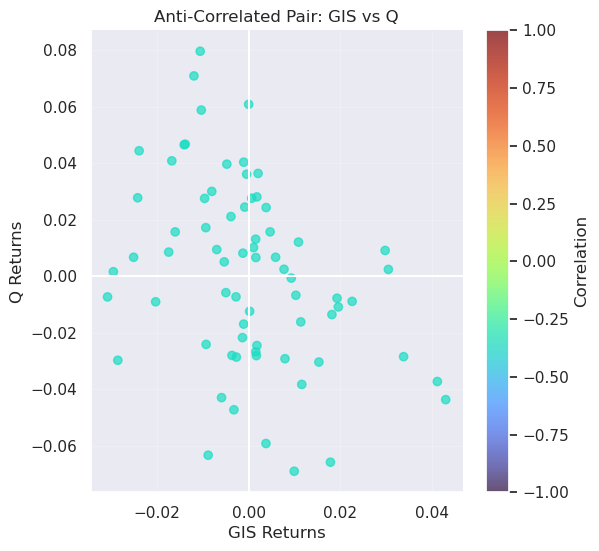

In [10]:
# part 4, task 3

corr_matrix.index.name = "Stock1"
corr_matrix.columns.name = "Stock2"

corr_pairs = (
    corr_matrix
    .stack()
    .reset_index(name="Correlation")
)

corr_pairs = corr_pairs[corr_pairs["Stock1"] != corr_pairs["Stock2"]]

corr_pairs["pair_key"] = corr_pairs.apply(
    lambda x: tuple(sorted([x["Stock1"], x["Stock2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("pair_key").drop(columns="pair_key")

anti_corr = corr_pairs.sort_values("Correlation")

s1, s2 = anti_corr.iloc[0][["Stock1", "Stock2"]]

corr_value = corr_matrix.loc[s1, s2]


plt.figure(figsize=(6, 6))
plt.scatter(per_data[s1], 
            per_data[s2], 
            alpha=0.7,
            c=[corr_value] * len(per_data),
            cmap="turbo",
            vmin=-1,
            vmax=1,)

plt.colorbar(label="Correlation")

plt.xlabel(f"{s1} Returns")
plt.ylabel(f"{s2} Returns")
plt.title(f"Anti-Correlated Pair: {s1} vs {s2}")

plt.axhline(0)
plt.axvline(0)
plt.grid(alpha=0.2)

plt.show()

## Part 4: The Market Map: Dimensionality Reduction (PCA & t-SNE)

**The Objective:** 
This is where we enter the "Black Magic" of quantitative research. Currently, your dataset has over 1000 dimensions (one for every every market day) and about 500 rows (one for every stock. If this is not yet the case, transpose your dataset). As humans, we cannot visualize 1000+-dimensional space. To find the "latent" structure of the market, we must use **Dimensionality Reduction**.

We will use two primary tools:
1.  **PCA (Principal Component Analysis)** PCA may tell us what percentage of the market's movement is driven by a single "Market Factor" (The first Principal Component).
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding) or UMAP:** Non-linear techniques that are incredibly powerful for visualization. They attempt to keep "similar" stocks close together in 2D space, effectively creating a "Topographical Map" of the S&P 500.

### Your Tasks:
1.  **The Scree Plot:** Run PCA on your normalized returns. Plot the "Explained Variance Ratio." How many "components" does it take to explain 50% of the market's movement?
2.  **The 2D Projection:** Use **t-SNE** (or UMAP) to project the ~500 stocks into a 2-dimensional scatter plot. 
3.  **The Sector Overlay:** Color-code the dots in your scatter plot by their **GICS Sector** (Information Technology, Energy, etc.). 
4.  **Identify the Outliers:** Annotate the map (such that the name of a stock is revealed when the mouse hovers over it). Find the stocks that are "Socially Distancing" i.e. those that sit far away from their sector peers or in the middle of a different cluster entirely.

### Critical Thinking Questions:
*   **The Market Factor:** In your PCA analysis, you will likely find that the first component (PC1) explains a massive amount of variance. What do you think PC1 represents in the real world? (Hint: If every stock goes down at the same time, what is that called?)*   **Portfolios:** How would a portfolio based on PC1 be advantageous compared to a portfolio based on PC2 ? How would a portfolio based on PC2 be advantageous compared to a portfolio based on PC1 ? (Hint: think in terms of variance) 
*   **Linear vs. Non-Linear:** Compare your correlation clustermap from Part 3 with your t-SNE map here. Which one makes it easier to spot "anomalous" companies that don't belong with their peers?
*   **The "Misplaced" Stock:** If you see a "Technology" stock sitting deep inside the "Healthcare" cluster in your 2D map, does that necessarily mean your code is wrong, or is the market telling you something about that company's actual revenue stream?

---

Components needed for 50% variance: 34


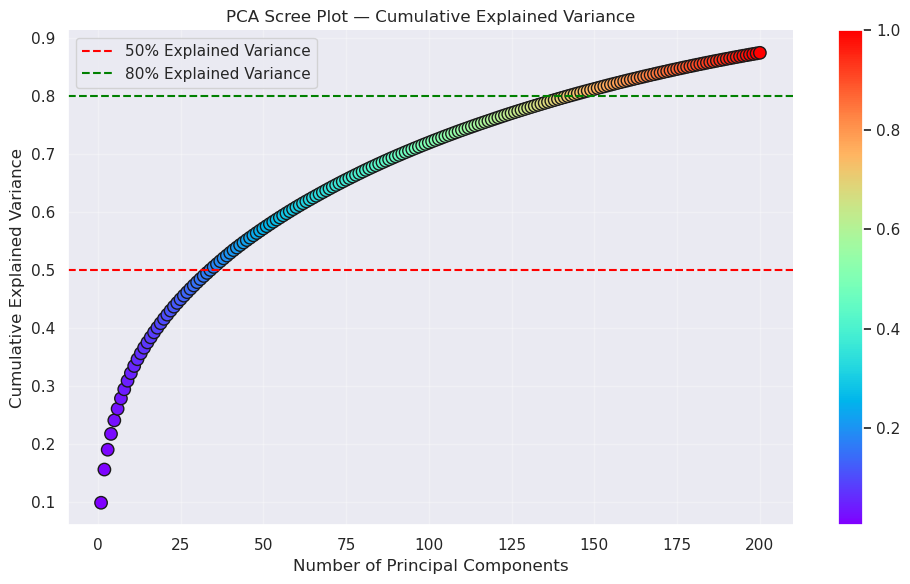

In [11]:
# part 4, task 1 & 2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

clean_data = per_data.dropna(axis=1)

X = clean_data.T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

nth = 200 # change n component to see the graph change, max = 489

pca = PCA(n_components=nth) 
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_

n_50 = np.argmax(np.cumsum(explained_var) >= 0.5) + 1
print("Components needed for 50% variance:", n_50)

cumulative_var = np.cumsum(explained_var)

components = np.arange(1, len(explained_var) + 1)

colors = components / components.max()

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    components,
    cumulative_var,
    c=colors,  # color by nth PC (match length)
    cmap='rainbow',
    s=80,       # dot size
    edgecolor='k'
)

plt.axhline(0.5, color='red', linestyle='--', label='50% Explained Variance')
plt.axhline(0.8, color='green', linestyle='--', label='80% Explained Variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — Cumulative Explained Variance")
plt.grid(alpha=0.3)

cbar = plt.colorbar(scatter)

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# part 4, task 3 & 4

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

sp500 = tables[0][["Symbol", "GICS Sector"]].copy()

sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)

ticker_to_sector = sp500.set_index("Symbol")["GICS Sector"].to_dict()

/tmp/ipykernel_28646/715014106.py:9: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [ ]:
# part 4, task 3 & 4

from sklearn.manifold import TSNE
import plotly.express as px

pca_30 = PCA(n_components=30)
X_pca = pca_30.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_pca)

tickers = clean_data.columns
sectors = [ticker_to_sector.get(t, "Unknown") for t in tickers]

df_plot = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "Ticker": tickers,
    "Sector": sectors
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="Sector",
    hover_name="Ticker",
    title="2D Market Map (t-SNE Projection of S&P 500)"
)

fig.update_layout(
    height=800,
    width=1000
    )

fig.show()

df_plot["dist"] = 0.0

for sector in df_plot["Sector"].unique():
    mask = df_plot["Sector"] == sector
    center_x = df_plot.loc[mask, "x"].mean()
    center_y = df_plot.loc[mask, "y"].mean()

    df_plot.loc[mask, "dist"] = np.sqrt(
        (df_plot.loc[mask, "x"] - center_x)**2 +
        (df_plot.loc[mask, "y"] - center_y)**2
    )

outliers = df_plot.sort_values("dist", ascending=False).head(10)
print(outliers[["Ticker", "Sector", "dist"]])

positions = [
    "top center", "bottom center",
    #"top left", "top right",
    #"bottom left", "bottom right"
]

text_positions = [positions[i % len(positions)] for i in range(len(outliers))]

fig.add_scatter(
    x=outliers["x"],
    y=outliers["y"],
    mode="markers+text",
    text=outliers["Ticker"],
    textposition=text_positions,
    marker=dict(
        size=12,
        color="white",
        line=dict(color="black", width=1)
    ),
    textfont=dict(
        size=14,
        color="white"
    ),
    name="Outliers"
)

fig.update_layout(
    height=800,
    width=1000
    )

fig.show()

    Ticker                  Sector       dist
226    HST             Real Estate  49.645908
192   FSLR  Information Technology  48.527119
462    VST               Utilities  45.171150
328    NRG               Utilities  45.134956
115   CSGP             Real Estate  35.144905
481     WY             Real Estate  35.102310
322    NEM               Materials  34.514122
284    LYV  Communication Services  26.346046
446   UBER             Industrials  21.799469
121   CVNA  Consumer Discretionary  20.924812


<Figure size 640x480 with 0 Axes>